In [1]:
from sklearn_extra.cluster import KMedoids
print("KMedoids working!")

KMedoids working!


K-Means Silhouette Score: 0.2848589191898987
K-Means ARI: 0.8974949815093207
K-Medoids Silhouette Score: 0.26597740204536796
K-Medoids ARI: 0.7263406645756675


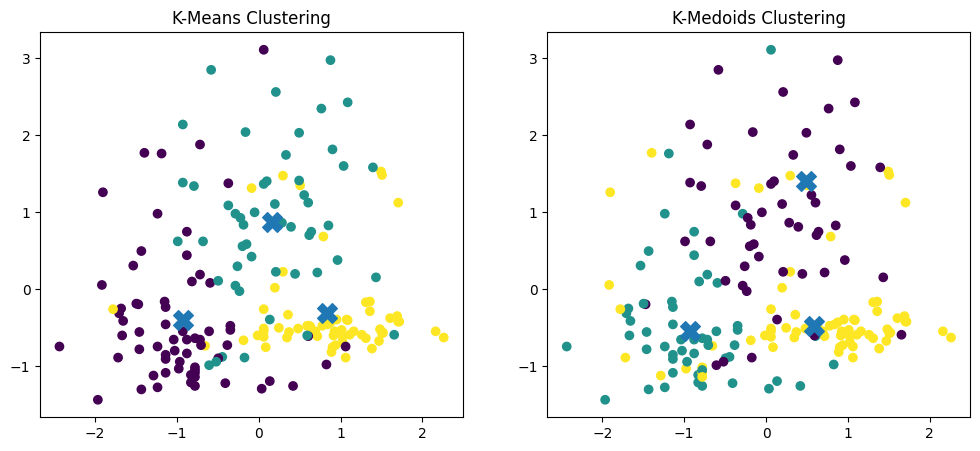

In [2]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from sklearn_extra.cluster import KMedoids

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# K-MEANS
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("K-Means ARI:", kmeans_ari)

# -------------------------
# K-MEDOIDS
# -------------------------
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids_labels = kmedoids.fit_predict(X_scaled)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Silhouette Score:", kmedoids_silhouette)
print("K-Medoids ARI:", kmedoids_ari)

# -------------------------
# Visualization (2 features)
# -------------------------
plt.figure(figsize=(12,5))

# K-Means Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=200)
plt.title("K-Means Clustering")

# K-Medoids Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmedoids_labels)
plt.scatter(kmedoids.cluster_centers_[:,0], kmedoids.cluster_centers_[:,1], marker='X', s=200)
plt.title("K-Medoids Clustering")

plt.show()